# [LAB-13] 5. ARIMA 모델링 - 연습문제

## 📚 서울 기온 보고서 — 그래서 내년 여름은 얼마나 더운가 (2)

### 당신은 서울시 기후정책과에서 기온 분석을 맡고 있는 연구원입니다.

지난 보고에서 표준 절차의 ③번까지 마쳤습니다. 계절 주기를 12로 확정했고, 가법으로 판정했고,
계절차분(12) 하나만으로 정상성을 얻었으며($d=0$, $D=1$, $s=12$),
ACF · PACF로 차수 후보의 **상한**($p \le 1$, $q \le 3$, $P \le 3$, $Q \le 2$)까지 좁혀 두었습니다.

이제 마지막 ④번입니다. 보고서를 넘겨보던 사무관이 묻습니다.
"차수 후보는 알겠습니다. 그런데 후보가 여럿이면 무엇을 쓰라는 말입니까?
**하나로 정해서**, 시민들이 정작 묻는 그 답 — 내년 여름 기온을 숫자로 적어 주세요."

그리고 한마디 덧붙입니다.
"다만 숫자 하나만 적으면 반드시 틀립니다. **얼마나 틀릴 수 있는지도 함께** 적으세요."

시계열 분석의 표준 절차 ① 계절 주기 확인 · 분해 → ② 차분 → ③ ACF · PACF → **④ ARIMA** 의
마지막 단계를 밟아, 모형을 하나로 확정하고 예측치를 구하세요.

### 💻 코드 작성

## #01. 준비작업

### 1. 라이브러리 참조

In [1]:
from jussam import load_data
from helpers import *

📦 연세대학교 주영아 교수가 제작한 라이브러리를 사용중입니다.
📧 Email(1): j.purplerose@yonsei.ac.kr
📧 Email(2): j.purplerose@gmail.com
📝 Website: https://juyounga.kr/
🔖 Version: 0.5.19


### 2. 데이터 가져오기 및 인덱스 설정

In [2]:
origin = load_data('temperatures_seoul')

df = my_ts.set_index(origin, "날짜", freq="MS")

print(f"데이터셋 크기: {df.shape[0]}행")
print(f"기간: {df.index[0]:%Y-%m} ~ {df.index[-1]:%Y-%m}")

df.head()

📚 1973년 1월부터 2023년 8월까지 서울의 월평균 기온 데이터 (출처: 기상청)


데이터셋 크기: 602행
기간: 1973-07 ~ 2023-08


,평균기온(℃)
날짜,
1973-07-01,26.816
1973-08-01,25.884
1973-09-01,20.323
1973-10-01,13.039
1973-11-01,4.723


### 3. 1~4단원이 확정한 파라미터

In [3]:
d = 0             # 1단원 : 일반차분 0회
D = 1             # 1단원 : 계절차분 1회
s = 12            # 1 · 2 · 3단원 : 계절 주기
p = 1             # 4단원 : AR(1) 모형
q = 3             # 4단원 : MA(3) 모형
P = 3             # 4단원 : 계절 AR(3) 모형
Q = 2             # 4단원 : 계절 MA(2) 모형

print(f"p 상한={p}, 차분 d={d}, q 상한={q}")
print(f"P 상한={P}, 계절차분 D={D}, Q 상한={Q}, 계절주기 s={s}")
print(f"모형 차수: ARIMA({p},{d},{q}) x ({P},{D},{Q})_{s}")

p 상한=1, 차분 d=0, q 상한=3
P 상한=3, 계절차분 D=1, Q 상한=2, 계절주기 s=12
모형 차수: ARIMA(1,0,3) x (3,1,2)_12


## #02. ARIMA 모형 적합

### 1. 모형 적합

- 이 모형은 로그 변환을 하지 않는다. (기온에 음수 값이 포함되어 있기 때문)

In [4]:
# 원본 데이터에서 다시 시작한다
source = my_ts.set_index(origin, "날짜", freq="MS")

best_fit = my_ts.fit_model(source, "평균기온(℃)",
                           p=p, d=d, q=q, P=P, D=D, Q=Q, s=s, log=False)

시도한 조합 96가지 | 적합 성공 96가지
AIC 최적: (1,0,1)(2,1,1,12)  |  BIC 최적: (1,0,1)(0,1,1,12)


,모형,p,d,q,P,D,Q,s,계수 수,AIC,BIC
순위,,,,,,,,,,,
1,"(1,0,1)(2,1,1,12)",1,0,1,2,1,1,12,6,2057.303,2083.584
2,"(1,0,3)(0,1,1,12)",1,0,3,0,1,1,12,6,2058.069,2084.350
3,"(1,0,3)(1,1,2,12)",1,0,3,1,1,2,12,8,2058.319,2093.360
4,"(1,0,1)(3,1,2,12)",1,0,1,3,1,2,12,8,2058.862,2093.903
5,"(1,0,1)(2,1,2,12)",1,0,1,2,1,2,12,7,2059.191,2089.851
6,"(1,0,1)(3,1,1,12)",1,0,1,3,1,1,12,7,2059.234,2089.895
7,"(1,0,2)(2,1,1,12)",1,0,2,2,1,1,12,7,2059.278,2089.939
8,"(1,0,1)(0,1,1,12)",1,0,1,0,1,1,12,4,2060.042,2077.562
9,"(1,0,1)(1,1,2,12)",1,0,1,1,1,2,12,6,2060.341,2086.622


### 2. 앞으로 1개 시즌 예측

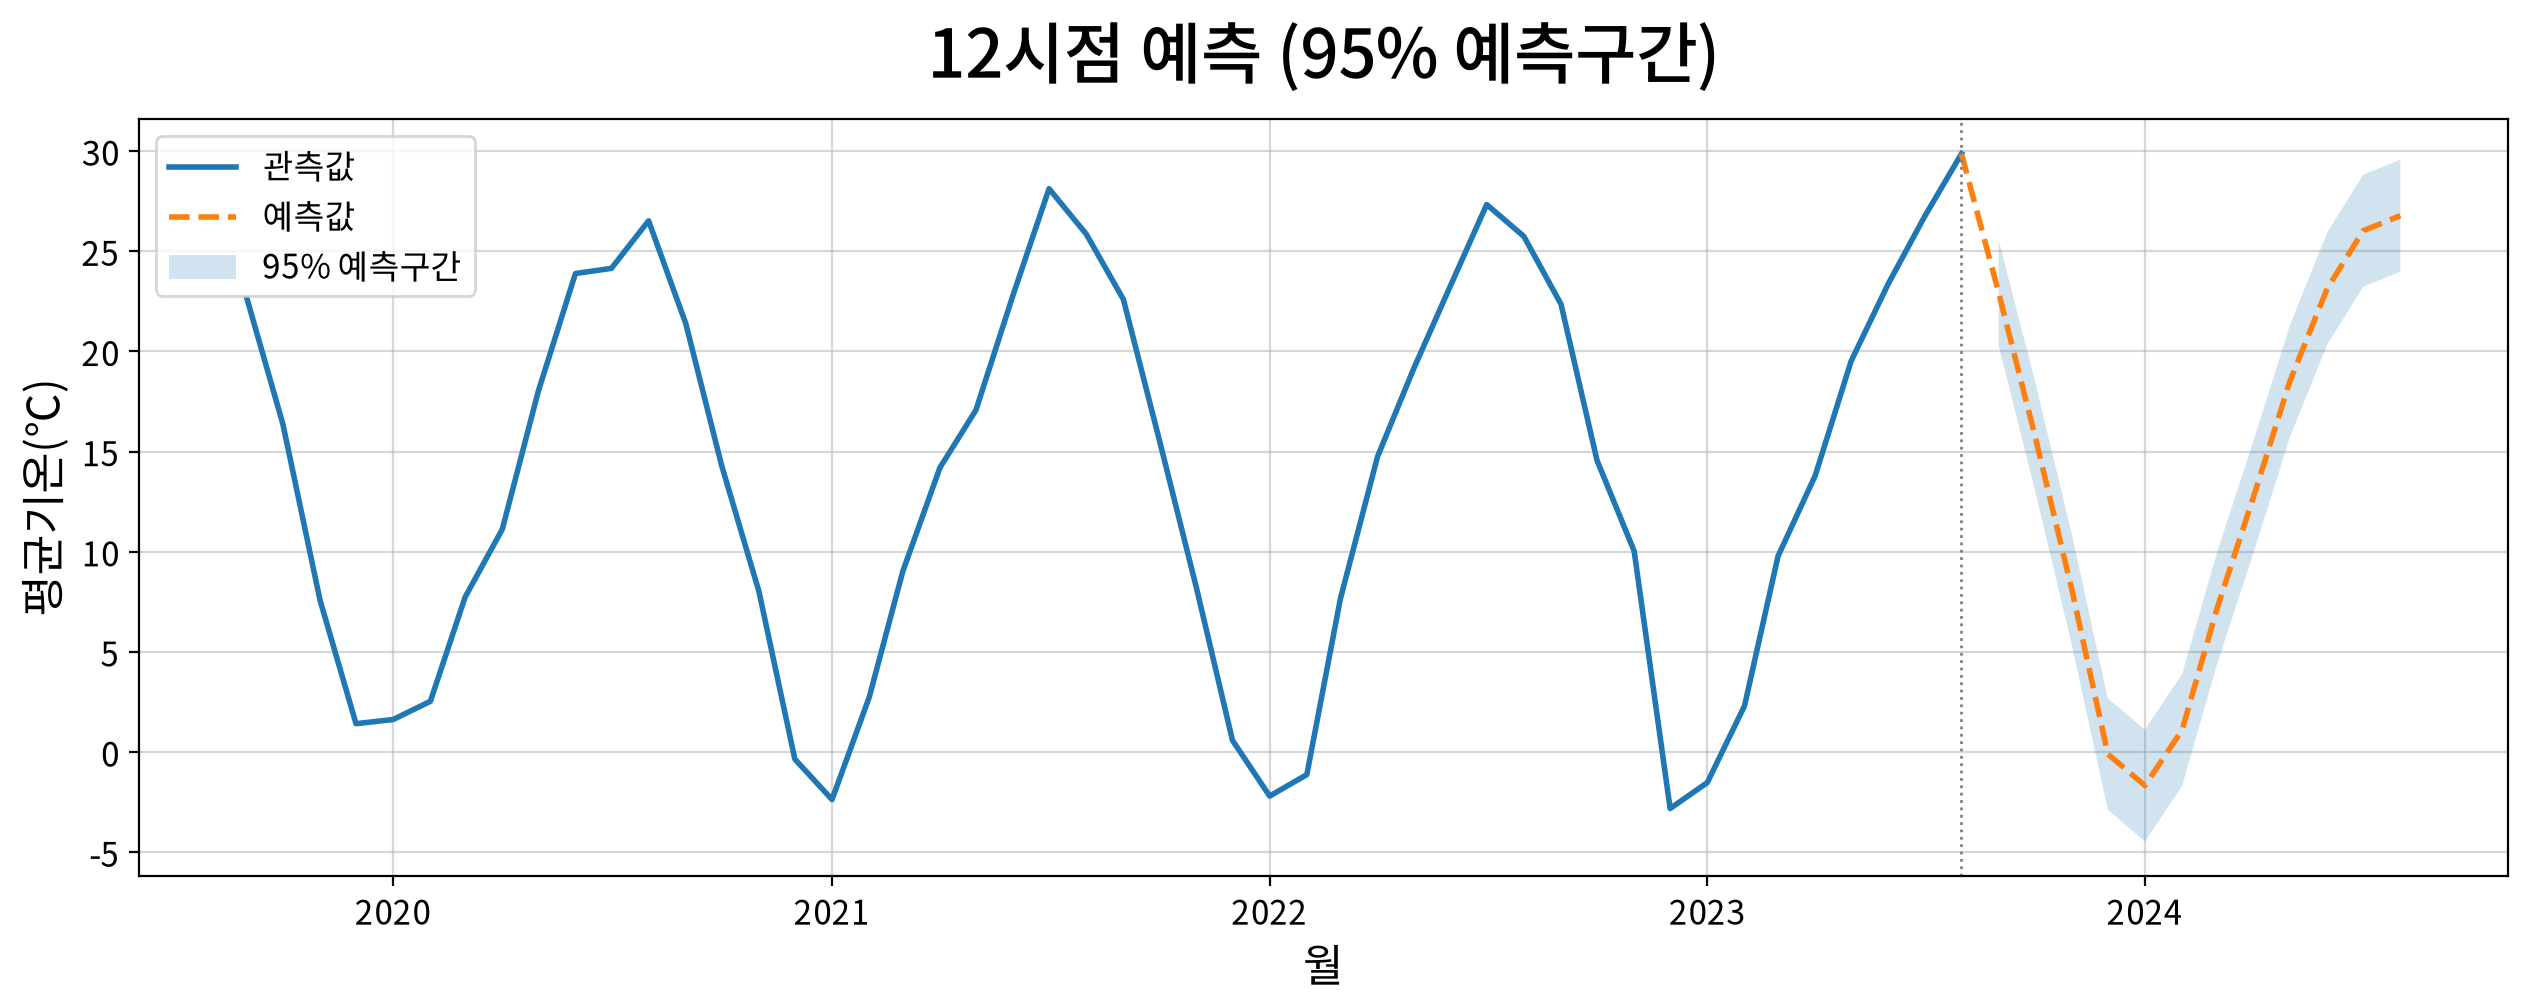

,pred,lower,upper
시점,,,
2023-09-01,22.927,20.290,25.563
2023-10-01,15.855,13.129,18.581
2023-11-01,8.119,5.354,10.884
2023-12-01,-0.094,-2.877,2.689
2024-01-01,-1.672,-4.463,1.119
2024-02-01,1.103,-1.691,3.898
2024-03-01,7.146,4.350,9.942
2024-04-01,12.828,10.031,15.625
2024-05-01,18.530,15.733,21.327


In [5]:
my_ts.predict(best_fit, steps=s, history=48,
              xlabel="월", ylabel="평균기온(℃)")

### 3. 예측구간의 폭 확인

- 사무관이 요구한 "얼마나 틀릴 수 있는가"에 답하려면 예측구간의 **폭**을 봐야 한다.
- 그래프는 이미 그렸으므로 `plot=False` 로 표만 다시 받는다.

In [6]:
pred_df = my_ts.predict(best_fit, steps=s, plot=False)

# 위쪽 끝에서 아래쪽 끝을 빼면 그 시점 예측의 불확실성 크기가 된다
pred_df["구간 폭"] = (pred_df["upper"] - pred_df["lower"]).round(3)

pred_df

,pred,lower,upper,구간 폭
시점,,,,
2023-09-01,22.927,20.290,25.563,5.273
2023-10-01,15.855,13.129,18.581,5.451
2023-11-01,8.119,5.354,10.884,5.530
2023-12-01,-0.094,-2.877,2.689,5.566
2024-01-01,-1.672,-4.463,1.119,5.582
2024-02-01,1.103,-1.691,3.898,5.589
2024-03-01,7.146,4.350,9.942,5.592
2024-04-01,12.828,10.031,15.625,5.594
2024-05-01,18.530,15.733,21.327,5.595


### 문제 풀이

#### 1. 4단원이 넘긴 상한 안에서 `fit_model()` 이 시도하는 차수 조합은 모두 몇 가지인가요?

- **정답**: `96`
- **복습 개념**: 차수 탐색의 크기입니다. **상한이 정해진 차수는 0부터 상한까지 모두 후보**이고, 네 차수가 서로 독립이므로 경우의 수는 **곱**으로 늘어납니다. $d$ · $D$ · $s$ 는 앞 단원이 확정한 값이라 탐색하지 않고 고정합니다.
- **풀이 접근**: 각 차수가 가질 수 있는 값의 개수를 세어 곱합니다. 상한이 $k$ 면 $0, 1, \dots, k$ 로 $k+1$ 가지입니다.
- **근거(계산 결과)**: $(1+1) \times (3+1) \times (3+1) \times (2+1) = 2 \times 4 \times 4 \times 3 = 96$ 이고, 출력의 `시도한 조합 96가지 | 적합 성공 96가지` 와 일치합니다.
- **함께 생각해 볼 점**: 항공 승객 데이터는 상한이 모두 1이어서 **16가지**였습니다. 상한이 조금 커졌을 뿐인데 여섯 배로 불어났습니다. 만약 4단원 없이 각 차수를 0~5로 뒀다면 $6^4 = 1296$ 가지를 돌려야 합니다. **ACF · PACF가 하는 일이 바로 이 숫자를 줄이는 것입니다.**

#### 2. AIC가 고른 모형과 BIC가 고른 모형이 서로 다릅니다. BIC가 1위로 지목한 모형의 계수는 몇 개인가요?

- **정답**: `4`
- **복습 개념**: AIC와 BIC의 벌점 차이입니다. 두 지표 모두 $-2\ln(L)$ 에 벌점을 더하지만, **AIC의 벌점은 $2k$, BIC의 벌점은 $k \ln(n)$** 입니다. 관측치가 많을수록 BIC의 벌점이 커져 **더 단순한 모형**을 고릅니다.
- **풀이 접근**: 결과표에서 `AIC 최적` 과 `BIC 최적` 으로 출력된 두 모형을 찾아, BIC 쪽 행의 `계수 수` 를 읽습니다.
- **근거(계산 결과)**: AIC 최적은 **(1,0,1)(2,1,1,12)** 로 계수 **6개**, BIC 최적은 **(1,0,1)(0,1,1,12)** 로 계수 **4개**입니다. 관측치가 602개이므로 $\ln(602) = 6.40$ 이고, BIC의 계수 하나당 벌점이 AIC(2점)의 **3배가 넘습니다.** 계수 2개 차이가 AIC에서는 4점이지만 BIC에서는 12.8점이라, 계절 AR 2개를 얹어 얻은 적합도 향상이 BIC에서는 본전을 못 뽑습니다.
- **헷갈리기 쉬운 점**: 항공 데이터에서는 AIC와 BIC가 같은 모형을 지목해 고민할 일이 없었습니다. **갈리는 것이 오히려 정상입니다.** 갈렸다는 것은 두 모형의 차이가 그만큼 미묘하다는 뜻이지, 어느 한쪽이 틀렸다는 뜻이 아닙니다.

#### 3. `fit_model()` 이 반환한 모형, 즉 예측에 실제로 쓰인 모형의 차수는 무엇인가요?

- **정답**: `(1,0,1)(2,1,1,12)`
- **복습 개념**: 모형 선택 기준의 채택입니다. `fit_model()` 은 **AIC가 가장 낮은 모형**을 반환합니다. AIC는 벌점이 약해 상대적으로 복잡한 모형을 고르는데, **예측이 목적일 때** 쓰는 기준이 바로 AIC입니다. BIC는 설명 · 해석이 목적일 때 씁니다.
- **풀이 접근**: 결과표의 1순위 행을 읽습니다. 표는 AIC 오름차순으로 정렬되어 있으므로 맨 위가 곧 채택된 모형입니다.
- **근거(계산 결과)**: 1순위 **(1,0,1)(2,1,1,12)**, AIC **2057.303** 입니다. BIC 최적인 (1,0,1)(0,1,1,12)는 AIC 기준으로는 **8위**(AIC 2060.042)이며, 1위와의 차이는 **2.739** 에 불과합니다.
- **함께 생각해 볼 점**: 사무관이 원한 것은 "내년 여름 기온"이라는 **예측치**입니다. 목적이 예측이므로 AIC를 따르는 것이 맞습니다. 만약 "서울 기온이 어떤 구조로 움직이는가"를 **설명**하는 보고서였다면 계수 4개짜리 BIC 모형이 더 나은 선택이었을 것입니다. **지표가 모형을 정하는 것이 아니라, 목적이 지표를 정합니다.**

#### 4. 사무관이 기다리는 답입니다. 예측된 2024년 8월 서울 평균기온은 몇 도인가요?

- **정답**: `26.775`
- **복습 개념**: 예측값의 생성입니다. `steps` 에 계절 주기를 넣으면 관측이 끝난 다음 시점부터 **한 시즌(12개월)** 을 내다봅니다. 자료가 2023년 8월까지이므로 2023년 9월부터 2024년 8월까지가 나옵니다.
- **풀이 접근**: 예측 표에서 `2024-08-01` 행의 `pred` 열을 읽습니다.
- **근거(계산 결과)**: **26.775℃** 입니다. 직전 관측인 2023년 8월(25.884℃)보다 약 0.9도 높습니다. 12개월 중 가장 더운 달로 예측되었고, 가장 추운 달은 2024년 1월의 **−1.672℃** 입니다.
- **자주 하는 실수**: "내년 여름"을 2024년 6월이나 7월로 잡기 쉽습니다. 예측표에서 가장 높은 값은 **8월(26.775)** 이고 7월은 26.021입니다. 서울 기온은 7월보다 8월이 더 높은 해가 많다는 계절 패턴을 모형이 학습한 결과입니다.

#### 5. 사무관은 "얼마나 틀릴 수 있는지도 적으라"고 했습니다. 2024년 8월 예측의 95% 예측구간은 얼마인가요?

- **정답**: `23.978 ~ 29.573`
- **복습 개념**: 예측구간(prediction interval)입니다. 예측은 점이 아니라 **폭으로 답해야 합니다.** `predict()` 가 돌려주는 `lower` · `upper` 가 그 폭이며, `alpha=0.05` 가 기본이라 **95% 구간**입니다.
- **풀이 접근**: 예측 표에서 `2024-08-01` 행의 `lower` 와 `upper` 를 함께 읽습니다.
- **근거(계산 결과)**: 점 예측 26.775℃ 를 중심으로 **23.978 ~ 29.573℃**, 폭은 **5.595도** 입니다. "2024년 8월 서울 평균기온은 약 **26.8℃** 로 예측되며, 95% 신뢰수준에서 **24.0 ~ 29.6℃** 사이일 것"이 사무관에게 제출할 문장입니다.
- **헷갈리기 쉬운 점**: 95% 예측구간은 "**평균기온**이 이 범위에 들어올 확률"이지, 그 달의 **일별 기온**이 24~30도 사이라는 뜻이 아닙니다. 예측 대상은 어디까지나 월평균입니다.